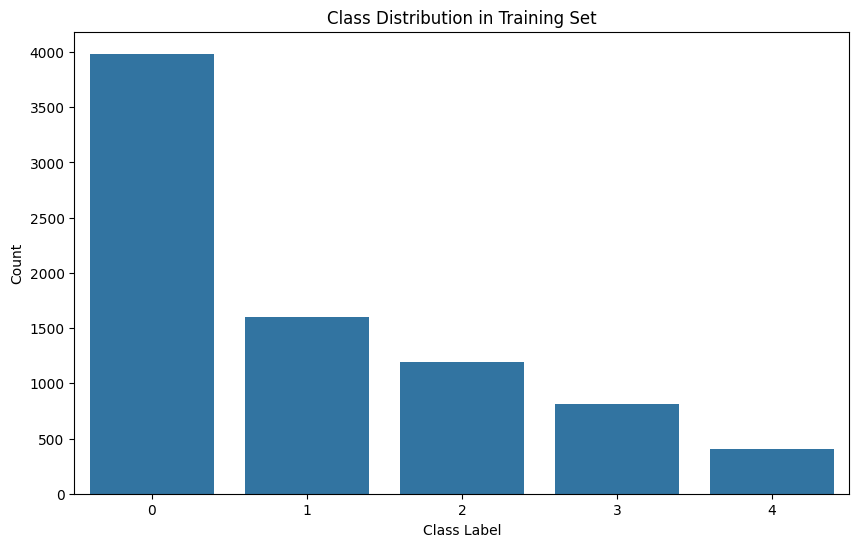

Label
0    3985
1    1604
2    1196
3     809
4     406
Name: count, dtype: int64
--- Train Set ---
Total examples: 8000
Batch Features shape: torch.Size([32, 206])
Batch Labels shape:   torch.Size([32])

--- Test Set ---
Total examples: 2000
Batch Features shape: torch.Size([32, 205])
Batch Labels shape:   torch.Size([32])



In [3]:
# read in packages
import torch
import pandas as pd
import numpy as np
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import Dataset, random_split
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns

# load dataset
class CSVDataset(Dataset):
    def __init__(self, csv_file_path):
        # Load the data using pandas
        self.df = pd.read_csv(csv_file_path)

        # last column is the label and others are features
        # Convert pandas DataFrame to numpy arrays, then to PyTorch tensors
        self.features = torch.from_numpy(self.df.iloc[:, :-1].values).float()
        self.labels = torch.from_numpy(self.df.iloc[:, -1].values).long()

    def __len__(self):
        # Return the number of rows in the DataFrame
        return len(self.df)

    def __getitem__(self, idx):
        # Return a single sample (features and label) as tensors
        return self.features[idx], self.labels[idx]

# create dataset instances
train_dataset = CSVDataset('/Users/edmundtsou/Desktop/JHU Files/Sophomore/Neural Networks from Scratch/Neural-Network-from-Scratch-Mystery-Project/Data/train.csv')
test_dataset = CSVDataset('/Users/edmundtsou/Desktop/JHU Files/Sophomore/Neural Networks from Scratch/Neural-Network-from-Scratch-Mystery-Project/Data/test.csv')

# check for class imbalances
# Extract labels from the train dataset
train_labels = [label.item() for _, label in train_dataset]

# Create a DataFrame for easier plotting
df_labels = pd.DataFrame(train_labels, columns=['Label'])

# Plot
plt.figure(figsize=(10, 6))
sns.countplot(data=df_labels, x='Label')
plt.title('Class Distribution in Training Set')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.show()

# Print exact counts
print(df_labels['Label'].value_counts().sort_index())

# create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

loaders = [("Train", train_loader), ("Test", test_loader)]

# print dataset info
for loader_name, loader in loaders:
    print(f"--- {loader_name} Set ---")
    print(f"Total examples: {len(loader.dataset)}")
    
    # Check the first batch to get shapes
    for features, labels in loader:
        print(f"Batch Features shape: {features.shape}")
        print(f"Batch Labels shape:   {labels.shape}")
        break 
    print()



=== Fold 1/5 ===
Class counts: [3188 1283  957  648  324]
              precision    recall  f1-score   support

           0      0.938     0.854     0.894       797
           1      0.889     0.822     0.854       321
           2      0.821     0.808     0.814       239
           3      0.554     0.925     0.693       161
           4      0.603     0.537     0.568        82

    accuracy                          0.832      1600
   macro avg      0.761     0.789     0.765      1600
weighted avg      0.855     0.832     0.837      1600


=== Fold 2/5 ===
Class counts: [3188 1283  957  647  325]
              precision    recall  f1-score   support

           0      0.878     0.877     0.878       797
           1      0.855     0.829     0.842       321
           2      0.736     0.711     0.723       239
           3      0.647     0.735     0.688       162
           4      0.551     0.531     0.541        81

    accuracy                          0.811      1600
   macro avg 

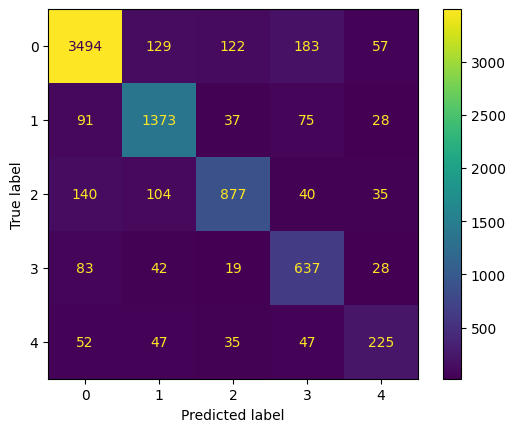

In [8]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt


# -----------------------------
# 1) Model
# -----------------------------
class MLP(nn.Module):
    def __init__(self, in_dim, num_classes, hidden=(512, 256), dropout=0.35):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [
                nn.Linear(prev, h),
                nn.LayerNorm(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev = h
        layers += [nn.Linear(prev, num_classes)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# -----------------------------
# 2) Batch helpers
# -----------------------------
def unpack_batch(batch):
    if isinstance(batch, (list, tuple)):
        x, y = batch
    else:
        x, y = batch["x"], batch["y"]
    return x, y

def to_xy(x, y, device="cpu"):
    x = x.detach().to(device)
    y = y.detach().to(device)

    if x.ndim > 2:
        x = x.view(x.size(0), -1)

    # one-hot -> indices
    if y.ndim > 1:
        y = y.argmax(dim=1)

    y = y.long()
    return x, y

@torch.no_grad()
def predict_loader(model, loader, device="cpu"):
    model.eval()
    all_pred, all_true = [], []
    for batch in loader:
        x, y = unpack_batch(batch)
        x, y = to_xy(x, y, device=device)
        logits = model(x)
        pred = torch.argmax(logits, dim=1)
        all_pred.append(pred.cpu().numpy())
        all_true.append(y.cpu().numpy())
    return np.concatenate(all_true), np.concatenate(all_pred)


# -----------------------------
# 3) Fold utilities
# -----------------------------
def infer_in_dim_and_num_classes(dataset, idx0=0):
    sample = dataset[idx0]
    x, y = unpack_batch(sample)

    # x
    if torch.is_tensor(x):
        x_shape = x.shape
    else:
        x_shape = torch.tensor(x).shape

    if len(x_shape) > 1:
        in_dim = int(np.prod(x_shape))
    else:
        in_dim = int(x_shape[0])

    # y
    if torch.is_tensor(y):
        y_shape = y.shape
        y_max = int(y.max().item()) if y.ndim == 0 else None
    else:
        y = torch.tensor(y)
        y_shape = y.shape
        y_max = int(y.max().item()) if y.ndim == 0 else None

    if len(y_shape) > 0 and y_shape[0] > 1:  # one-hot
        num_classes = int(y_shape[0])
    else:
        # if scalar class ids, we’ll compute K later from labels
        num_classes = None

    return in_dim, num_classes

def get_labels_array(dataset, indices):
    ys = []
    for i in indices:
        sample = dataset[i]
        _, y = unpack_batch(sample)
        if torch.is_tensor(y):
            if y.ndim > 0:
                y = y.argmax().item() if y.numel() > 1 else y.item()
            else:
                y = y.item()
        else:
            y = np.asarray(y)
            y = int(y.argmax()) if y.ndim > 0 else int(y)
        ys.append(int(y))
    return np.array(ys, dtype=np.int64)

def compute_class_weights_from_labels(y_train, K, device):
    counts = np.bincount(y_train, minlength=K)
    weights = counts.sum() / (K * np.maximum(counts, 1))
    return torch.tensor(weights, dtype=torch.float32, device=device), counts


# -----------------------------
# 4) Train one fold
# -----------------------------
def train_one_fold(
    train_loader,
    val_loader,
    in_dim,
    K,
    class_weights,
    device="cpu",
    hidden=(512, 256),
    dropout=0.35,
    lr=1e-3,
    weight_decay=1e-4,
    epochs=40,
    use_focal=True,
    patience=6,
):
    model = MLP(in_dim, K, hidden=hidden, dropout=dropout).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_macro = -1.0
    best_state = None
    bad = 0

    for ep in range(1, epochs + 1):
        model.train()
        for batch in train_loader:
            x, y = unpack_batch(batch)
            x, y = to_xy(x, y, device=device)

            logits = model(x)

            if not use_focal:
                loss = F.cross_entropy(logits, y, weight=class_weights)
            else:
                gamma = 2.0
                ce = F.cross_entropy(logits, y, weight=class_weights, reduction="none")
                p = torch.softmax(logits, dim=1).gather(1, y.view(-1, 1)).squeeze(1).clamp(1e-6, 1.0)
                loss = ((1 - p) ** gamma * ce).mean()

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        # validate
        y_true, y_pred = predict_loader(model, val_loader, device=device)
        macro = f1_score(y_true, y_pred, average="macro")

        # early stopping on macro-F1
        if macro > best_macro + 1e-4:
            best_macro = macro
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model


# -----------------------------
# 5) Cross-validation runner
# -----------------------------
def cross_validate_mlp(
    base_loader,
    n_splits=5,
    batch_size=128,
    num_workers=0,
    device=None,
    random_state=0,
):
    if device is None:
        device = "mps" if torch.backends.mps.is_available() else "cpu"

    dataset = base_loader.dataset
    N = len(dataset)
    all_indices = np.arange(N)

    # labels for stratified split
    y_all = get_labels_array(dataset, all_indices)
    K = int(y_all.max()) + 1

    in_dim, K_from_onehot = infer_in_dim_and_num_classes(dataset, idx0=0)
    if K_from_onehot is not None:
        K = K_from_onehot

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    all_true, all_pred = [], []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(all_indices, y_all), 1):
        print(f"\n=== Fold {fold}/{n_splits} ===")

        train_ds = Subset(dataset, all_indices[tr_idx])
        val_ds   = Subset(dataset, all_indices[va_idx])

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                                  num_workers=num_workers, pin_memory=False)
        val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                                  num_workers=num_workers, pin_memory=False)

        y_train_fold = y_all[tr_idx]
        class_w, counts = compute_class_weights_from_labels(y_train_fold, K, device=device)
        print("Class counts:", counts)

        model = train_one_fold(
            train_loader, val_loader,
            in_dim=in_dim, K=K,
            class_weights=class_w,
            device=device,
            hidden=(512, 256),
            dropout=0.35,
            lr=1e-3,
            weight_decay=1e-4,
            epochs=40,
            use_focal=True,     # helps small class
            patience=6,
        )

        y_t, y_p = predict_loader(model, val_loader, device=device)

        print(classification_report(y_t, y_p, digits=3))
        all_true.append(y_t)
        all_pred.append(y_p)

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)

    print("\n=== Cross-validated performance (MLP) ===")
    print(classification_report(y_true, y_pred, digits=3))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.show()

    return y_true, y_pred


# -----------------------------
# 6) Run CV
# -----------------------------
# Use your existing train_loader as the "base_loader" (only for dataset reference).
y_true, y_pred = cross_validate_mlp(
    base_loader=train_loader,
    n_splits=5,
    batch_size=128,     # adjust
    num_workers=0,      # adjust
    random_state=0,
)
